# Extreme Year Analysis: Cross-Basin Comparison & Final Ordering

##### Compares Pearson-III results (sample skew vs weighted skew), validates rankings across Russian River basins, and produces the final extreme year ordering for USACE HMS calibration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.insert(0, '../..')
from pathlib import Path
from UCB_training.UCB_utils import clean_df
from UCB_training.UCB_plotting import plot_availability, plot_flow_precip, SPLIT_COLORS, plot_basin_extremeness, plot_basin_flow_precip_extremeness


PLOT_DIR = Path('extreme_year_analysis/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df_sample = pd.read_csv('extreme_year_analysis/data/peak_flow_analysis_sample_skew.csv')
df_weighted = pd.read_csv('extreme_year_analysis/data/peak_flow_analysis_weighted_skew.csv')

df_sample.set_index('water_year', inplace=True)
df_weighted.set_index('water_year', inplace=True)

BASINS = ['Calpella', 'Guerneville', 'Hopland', 'Warm Springs']

print(f"Years: {df_sample.index.min()}–{df_sample.index.max()} ({len(df_sample)} total)")
df_sample - df_weighted

Years: 1995–2009 (15 total)


,Calpella,Guerneville,Hopland,Warm Springs
water_year,,,,
1995,0.001598,0.001019,-0.000978,0.000041
1996,-0.005016,-0.002298,0.003155,-0.000050
1997,-0.000320,0.000339,0.000992,-0.000055
1998,-0.003494,-0.001293,0.001522,-0.000027
1999,-0.004868,-0.003259,0.003330,-0.000102
2000,-0.001629,-0.002676,0.002708,-0.000008
2001,0.002437,0.002181,-0.001924,0.000077
2002,-0.005032,-0.000669,0.002375,-0.000030
2003,-0.001968,-0.000407,0.000837,0.000036


##### Almost identical, go with no skew based on latest talk to Matt.

In [4]:
df_sample

,Calpella,Guerneville,Hopland,Warm Springs
water_year,,,,
1995,0.044105,0.067190,0.069832,0.068169
1996,0.465843,0.683687,0.566303,0.750820
1997,0.149513,0.116266,0.206295,0.224728
1998,0.301463,0.213929,0.243480,0.181018
1999,0.542775,0.592487,0.492186,0.660808
2000,0.753721,0.653667,0.631857,0.809223
2001,0.906501,0.937719,0.953273,0.928737
2002,0.482655,0.783090,0.665496,0.780542
2003,0.221630,0.160668,0.195910,0.077645


In [5]:
ranks = df_sample.rank(ascending=True).astype(int)
ranks['mean_rank'] = ranks[BASINS].mean(axis=1)
ranks.sort_values('mean_rank', ascending=True, inplace=True)

print("Per-Basin Ranks (1=wettest, 15=driest)\n")
ranks

Per-Basin Ranks (1=wettest, 15=driest)



,Calpella,Guerneville,Hopland,Warm Springs,mean_rank
water_year,,,,,
1995,1,2,2,1,1.50
2006,2,1,1,3,1.75
2003,4,4,3,2,3.25
1997,3,3,4,5,3.75
1998,5,5,5,4,4.75
2004,6,6,6,7,6.25
2008,10,7,9,6,8.00
1999,9,8,7,9,8.25
1996,7,10,8,10,8.75


In [6]:
n = 3
print(f"Top {n} Wettest (lowest exceedance = biggest floods) per Basin")
for b in BASINS:
    top_wet = ranks.nsmallest(n, b).index.tolist()
    print(f"{b:15s}: {top_wet}")

consensus_wet = set.intersection(*[set(ranks.nsmallest(n, b).index) for b in BASINS])
print(f"\n  Consensus wet (all 4 basins agree): {sorted(consensus_wet) if consensus_wet else 'NONE'}")

print(f"\nTop {n} Driest (highest exceedance = smallest peaks) per Basin")
for b in BASINS:
    top_dry = ranks.nlargest(n, b).index.tolist()
    print(f"  {b:15s}: {top_dry}")

consensus_dry = set.intersection(*[set(ranks.nlargest(n, b).index) for b in BASINS])
print(f"\nConsensus dry (all 4 basins agree): {sorted(consensus_dry) if consensus_dry else 'NONE'}")

all_wet = set.union(*[set(ranks.nsmallest(n, b).index) for b in BASINS])
all_dry = set.union(*[set(ranks.nlargest(n, b).index) for b in BASINS])
swing_wet = all_wet - consensus_wet
swing_dry = all_dry - consensus_dry

if swing_wet:
    print(f"\nSwing wet years (in some basins' top {n} but not all): {sorted(swing_wet)}")
if swing_dry:
    print(f"Swing dry years (in some basins' top {n} but not all): {sorted(swing_dry)}")

Top 3 Wettest (lowest exceedance = biggest floods) per Basin
Calpella       : [1995, 2006, 1997]
Guerneville    : [2006, 1995, 1997]
Hopland        : [2006, 1995, 2003]
Warm Springs   : [1995, 2003, 2006]

  Consensus wet (all 4 basins agree): [1995, 2006]

Top 3 Driest (highest exceedance = smallest peaks) per Basin
  Calpella       : [2009, 2001, 2007]
  Guerneville    : [2001, 2007, 2009]
  Hopland        : [2001, 2009, 2005]
  Warm Springs   : [2001, 2007, 2000]

Consensus dry (all 4 basins agree): [2001]

Swing wet years (in some basins' top 3 but not all): [1997, 2003]
Swing dry years (in some basins' top 3 but not all): [2000, 2005, 2007, 2009]


##### Wettest: [1995, 2006] in all 4 basins top 3 (and usually #1 or #2). 1997 vs 2003 can be debatable. 1995 and 2006 top 2 wet years?
##### Driest: [2001] in all, #1 for 3 basins. [2009, 2007] in 3 basins. 

In [7]:
# --- Basin config (from YAML target_variables + dynamic_inputs) ---
BASIN_TARGET_COLS = {
    'Calpella': 'NR CALPELLA FLOW COE CPL',
    'Hopland': 'NR HOPLAND FLOW COE HOP',
    'Guerneville': 'NR GUERNEVILLE FLOW COE GRN',
    'Warm Springs': 'LAKE SONOMA FLOW-RES IN CALC-VAL-SHIFT-SMOOTH',
}

BASIN_PRECIP_COLS = {
    'Calpella': ['EF RUSSIAN 20 PRECIP-INC SCREENED'],
    'Hopland': ['RUSSIAN 60 PRECIP-INC SCREENED', 'RUSSIAN 70 PRECIP-INC SCREENED', 'WF RUSSIAN PRECIP-INC SCREENED'],
    'Warm Springs': ['DRY CREEK 20 PRECIP-INC SCREENED', 'DRY CREEK 30 PRECIP-INC SCREENED'],
    'Guerneville': ['BIG SULPHUR CR PRECIP-INC SCREENED', 'DRY CREEK 10 PRECIP-INC SCREENED',
                    'EF RUSSIAN 20 PRECIP-INC SCREENED', 'GREEN VALLEY PRECIP-INC SCREENED',
                    'LAGUNA PRECIP-INC SCREENED', 'RUSSIAN 20 PRECIP-INC SCREENED',
                    'RUSSIAN 30 PRECIP-INC SCREENED', 'RUSSIAN 40 PRECIP-INC SCREENED',
                    'RUSSIAN 50 PRECIP-INC SCREENED', 'RUSSIAN 60 PRECIP-INC SCREENED',
                    'RUSSIAN 70 PRECIP-INC SCREENED', 'SANTA ROSA CR 10 PRECIP-INC SCREENED',
                    'SANTA ROSA CR 20 PRECIP-INC SCREENED', 'WF RUSSIAN PRECIP-INC SCREENED'],
}

DATA_DIR = '../../russian_river_data'
df_all = clean_df(pd.read_csv(f'{DATA_DIR}/daily.csv', low_memory=False))
basin_data = {}

for basin, flow_col in BASIN_TARGET_COLS.items():
    precip_cols = BASIN_PRECIP_COLS[basin]
    mean_precip = df_all[precip_cols].mean(axis=1)

    bdf = pd.DataFrame({'flow': df_all[flow_col], 'precip': mean_precip}, index=df_all.index)
    bdf.index.name = 'date'
    bdf['water_year'] = np.where(bdf.index.month >= 10, bdf.index.year + 1, bdf.index.year)

    nans = bdf['flow'].isna().sum()
    basin_data[basin] = bdf
    print(f"{basin}: {len(bdf)} days, flow='{flow_col}', NaN={nans} ({nans/len(bdf)*100:.1f}%), precip=mean of {len(precip_cols)} cols")

SPLITS = {
    'Train': ('1994-10-01', '2002-09-30'),
    'Validation': ('2002-10-01', '2005-09-30'),
    'Test': ('2005-10-01', '2009-09-30')}

print(f"\nSplits: Train WY1995-2002 | Val WY2003-2005 | Test WY2006-2009")

Calpella: 5479 days, flow='NR CALPELLA FLOW COE CPL', NaN=722 (13.2%), precip=mean of 1 cols
Hopland: 5479 days, flow='NR HOPLAND FLOW COE HOP', NaN=542 (9.9%), precip=mean of 3 cols
Guerneville: 5479 days, flow='NR GUERNEVILLE FLOW COE GRN', NaN=493 (9.0%), precip=mean of 14 cols
Warm Springs: 5479 days, flow='LAKE SONOMA FLOW-RES IN CALC-VAL-SHIFT-SMOOTH', NaN=92 (1.7%), precip=mean of 2 cols

Splits: Train WY1995-2002 | Val WY2003-2005 | Test WY2006-2009


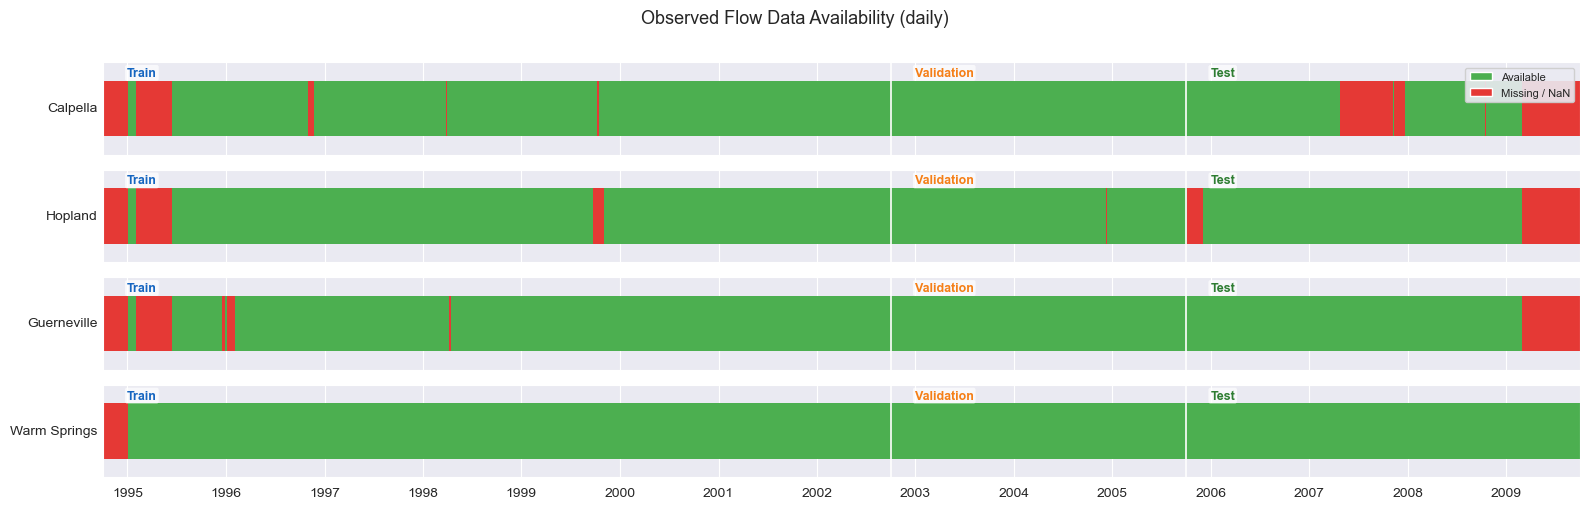

In [8]:
plot_availability(basin_data, SPLITS, save_path=PLOT_DIR / 'data_availability_daily.png')

##### Out of the years that ranked high on wetness/dryness, we have **1995** for all basins, **2006** for Hopland but seems fine and ranked top for all, **2007** for Calpella, seems dry / top 3 in all basins, AND more significantly **2009** for whch we have a significant chunk missing for 3 basins


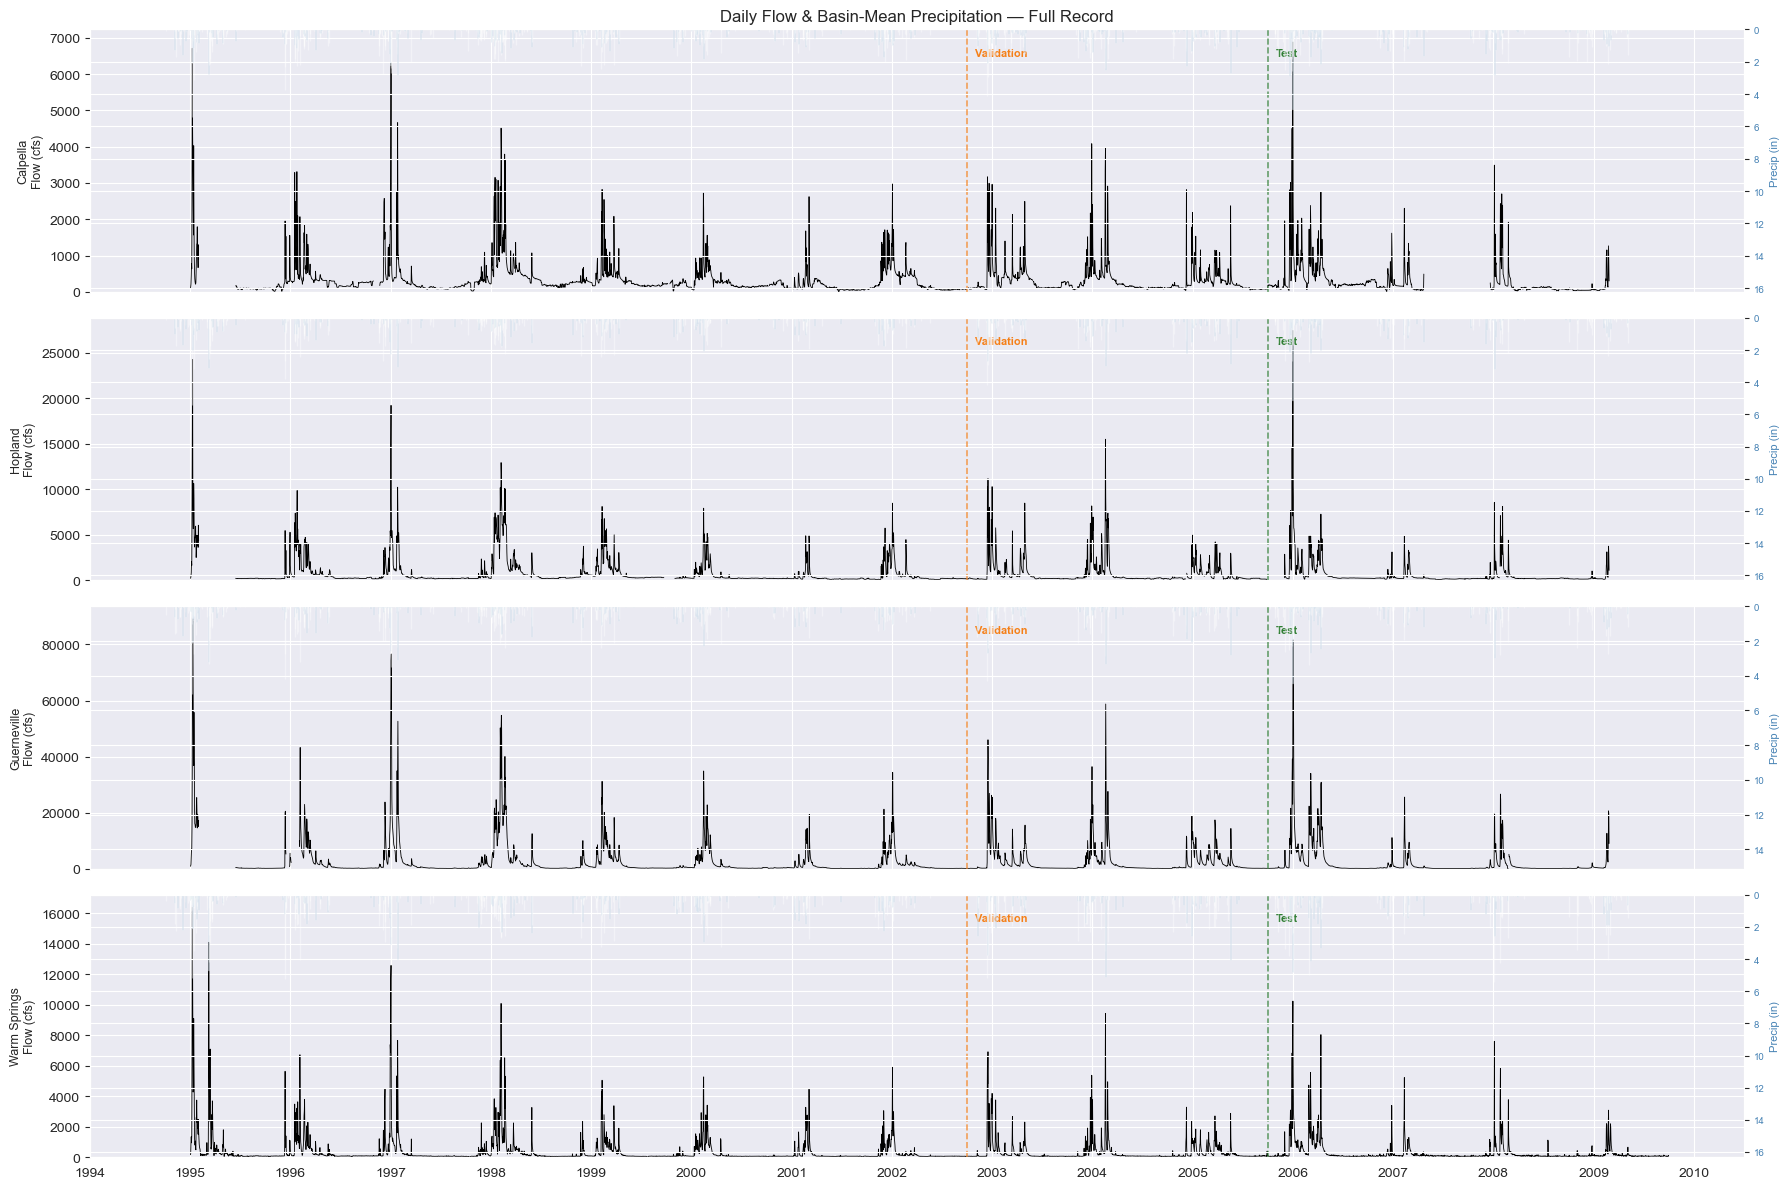

In [9]:
plot_flow_precip(basin_data, SPLITS, save_path=PLOT_DIR / 'flow_precip_full_record.png')

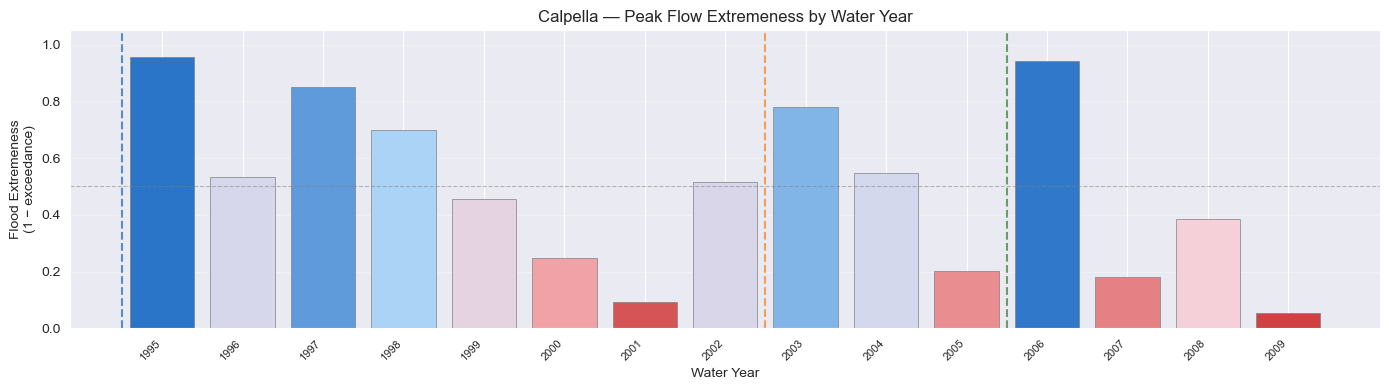

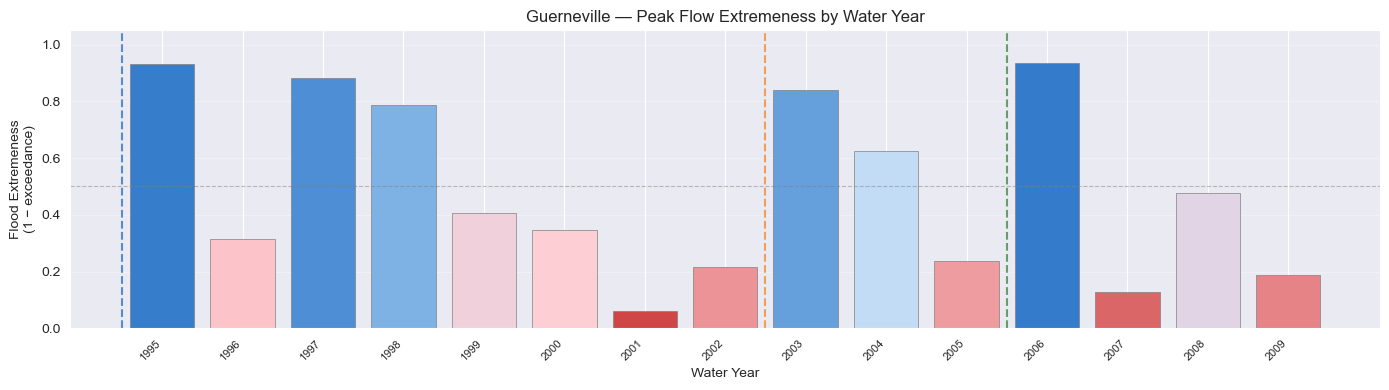

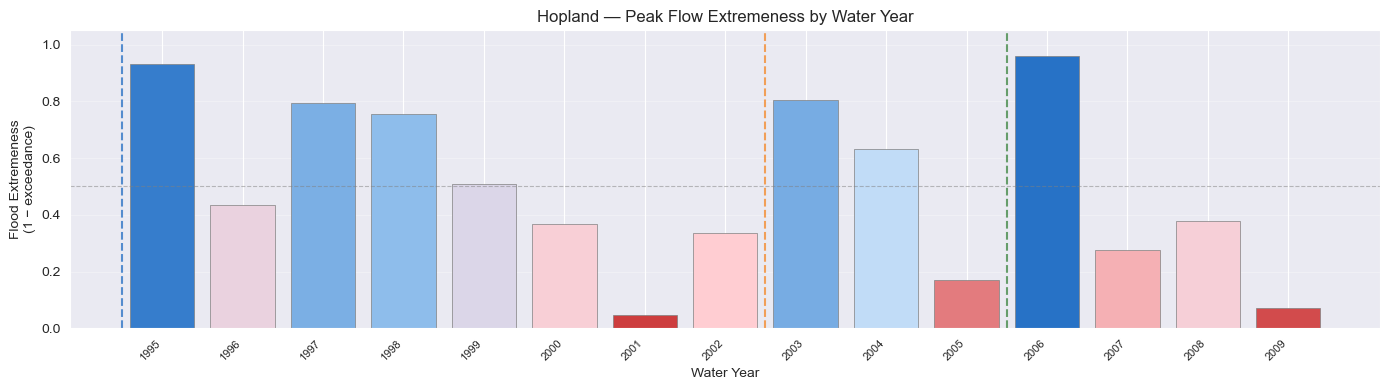

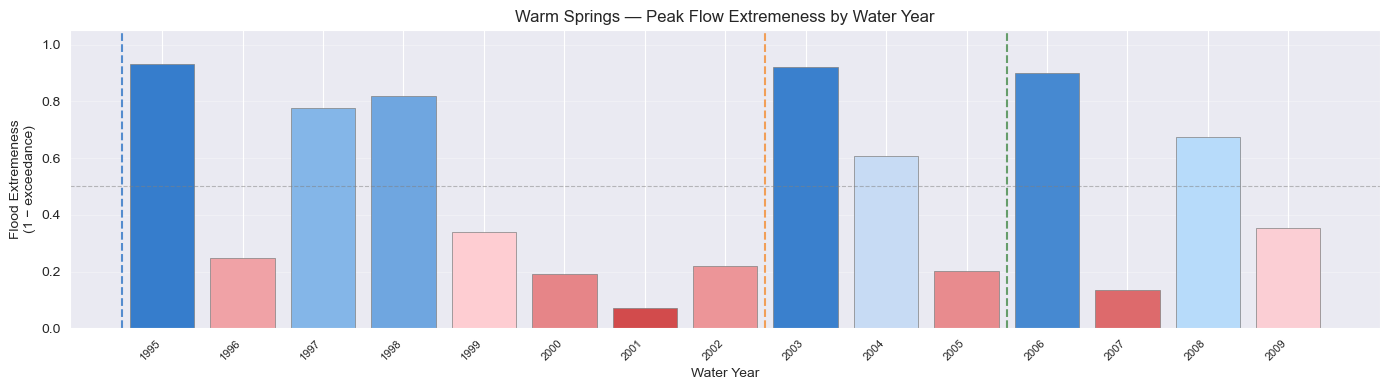

In [10]:
for basin in BASINS:
    plot_basin_extremeness(basin, df_sample, splits=SPLITS, save_path=PLOT_DIR / f'extremeness_bars_{basin.lower().replace(" ", "_")}.png')

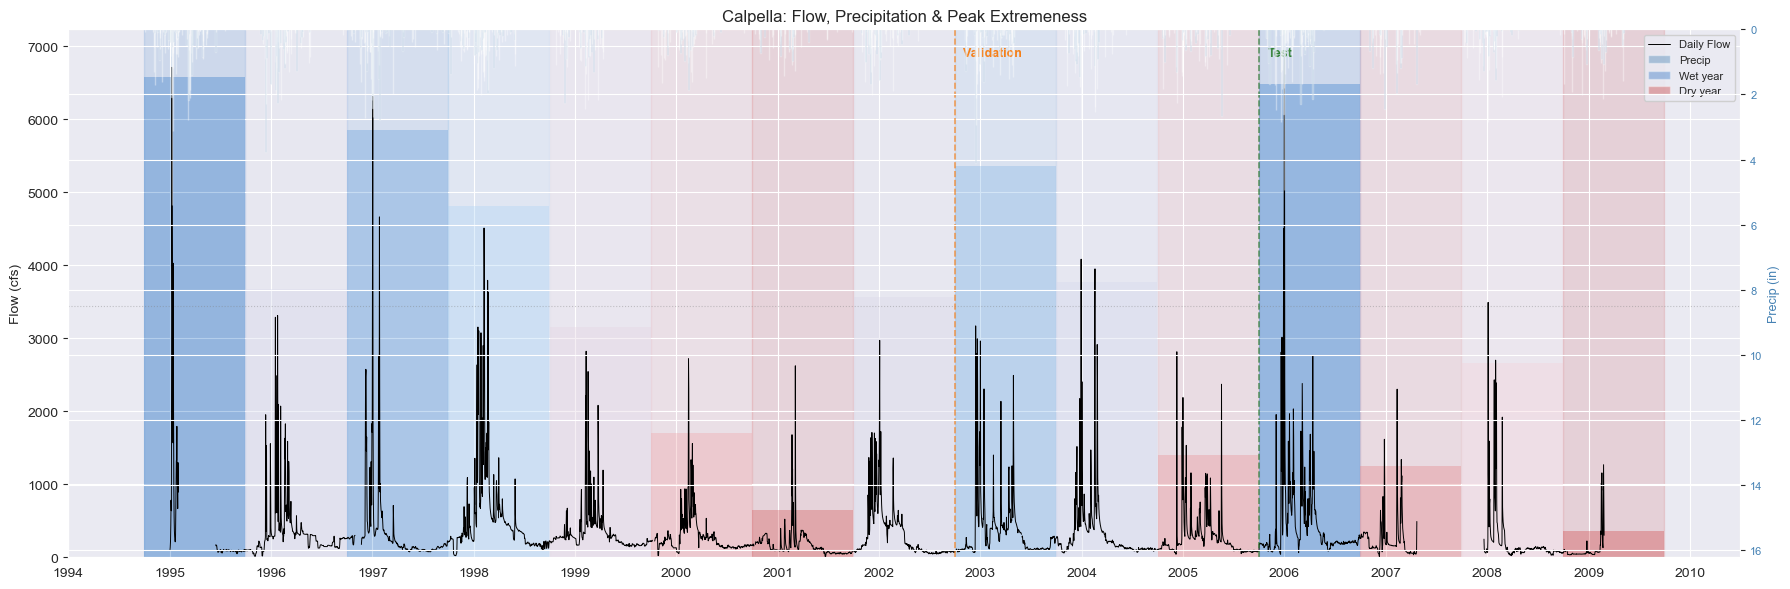

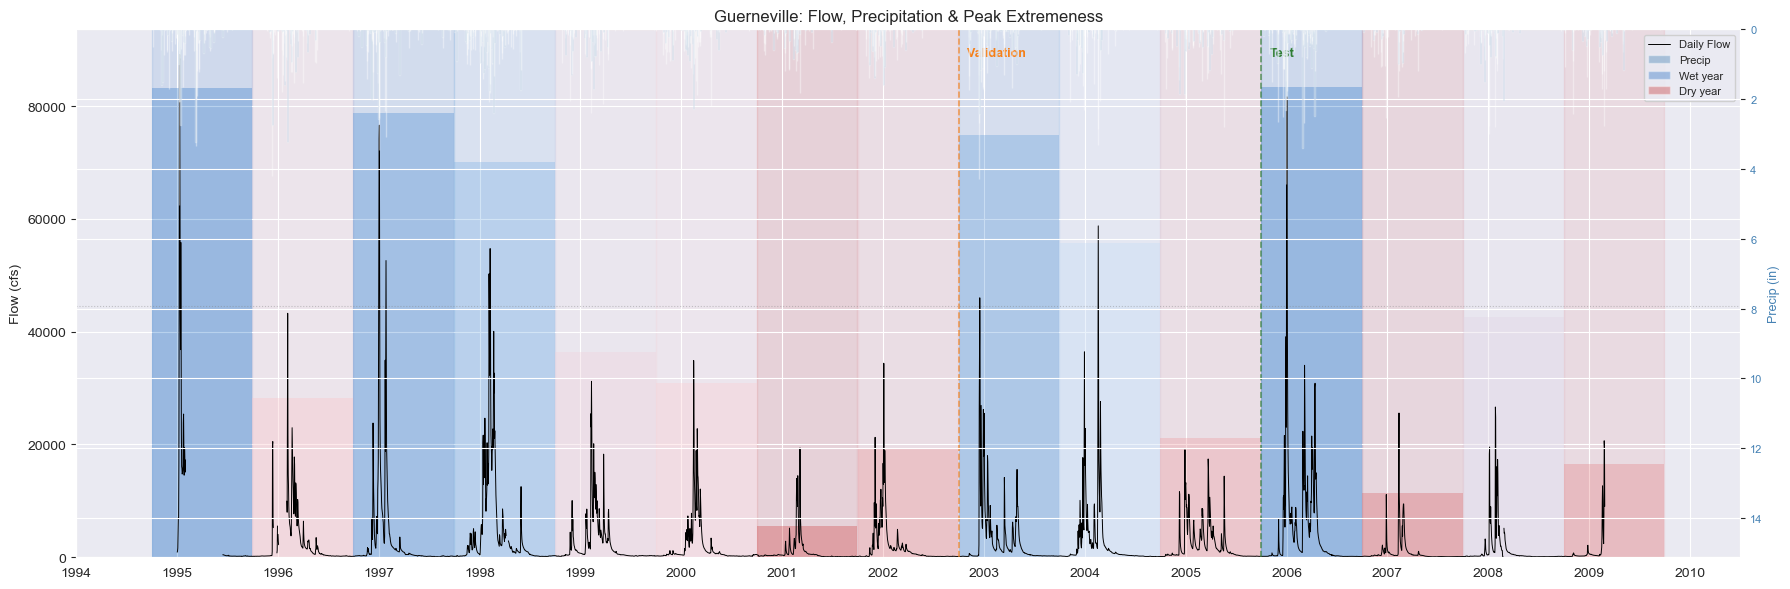

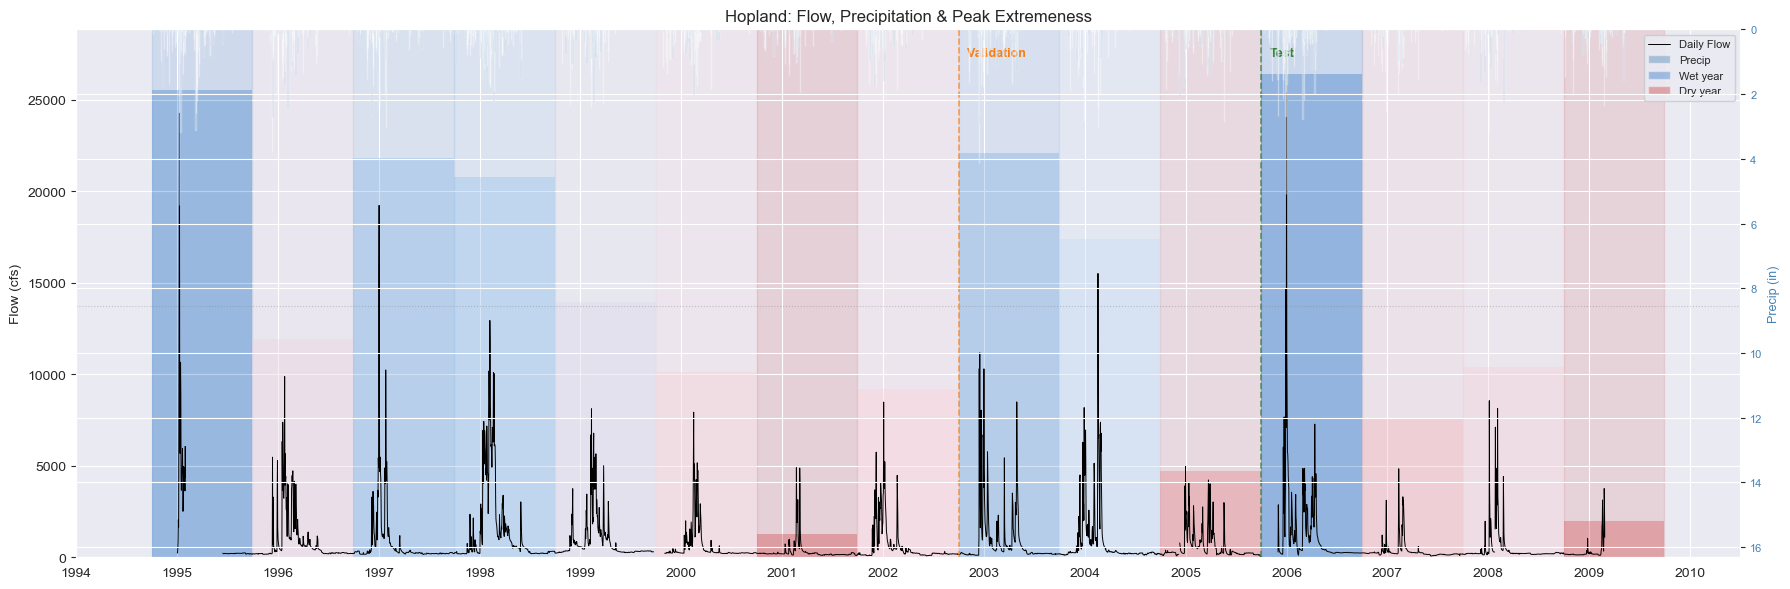

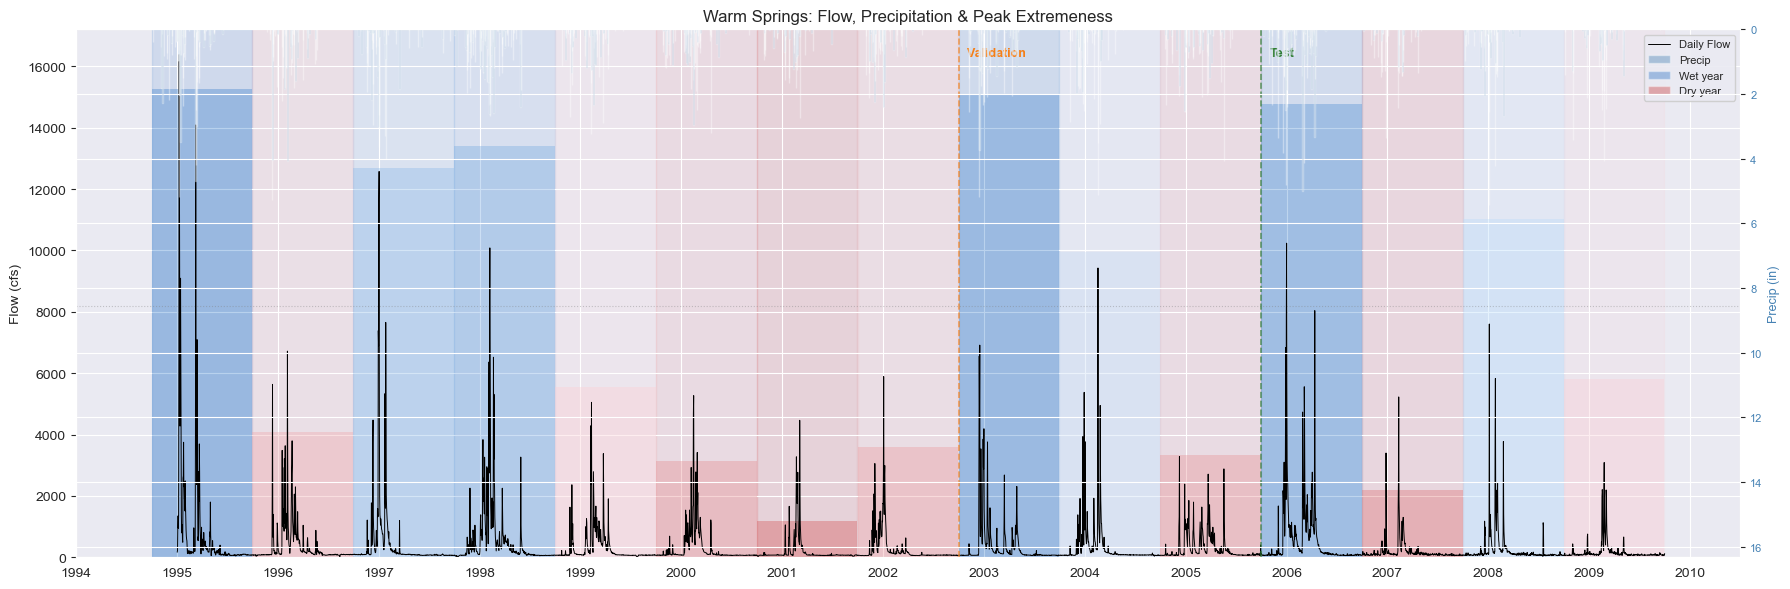

In [11]:
for basin in BASINS:
    plot_basin_flow_precip_extremeness(basin, basin_data, df_sample, splits=SPLITS, save_path=PLOT_DIR / f'flow_precip_extremeness_{basin.lower().replace(" ", "_")}.png')